<a href="https://colab.research.google.com/github/malhan21ab/8week/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Untitled4_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

5572
Точность (Accuracy): 0.9839

Отчет классификации:
              precision    recall  f1-score   support

     Не спам       0.98      1.00      0.99       965
        Спам       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



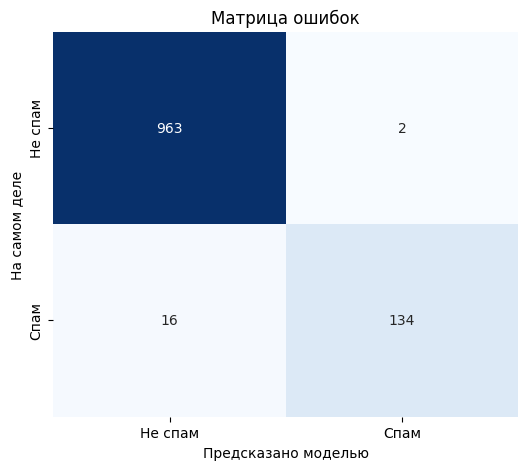

Введите текст сообщения для проверки: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Спам


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df = pd.read_csv('spam.csv', encoding='latin-1')

df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print(len(df))


X = df['text']
y = df['label_num']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)


model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)


print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred, target_names=['Не спам', 'Спам']))

# Построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Не спам', 'Спам'],
            yticklabels=['Не спам', 'Спам'])
plt.xlabel('Предсказано моделью')
plt.ylabel('На самом деле')
plt.title('Матрица ошибок')
plt.show()
user_input = input("Введите текст сообщения для проверки: ")


data = [user_input]


vect = vectorizer.transform(data)


prediction = model.predict(vect)


if prediction[0] == 1:
    print("Спам")
else:
    print("Не спам")